# Лабораторная работа 3. Классификация. Нейронные сети

## Описание работы

**Цель работы:** изучение методов классификации данных, реализованные в библиотеке Scikit-Learn, а также ознакомление с нейронными сетями с использованием библиотек TensorFlow и TensorBoard.

**Постановка задачи:**

1. Необходимо выбрать и подготовить датасет для классификации, затем построить классификационные модели с помощью пяти методов:

    - Наивный Байесовский классификатор (GaussianNB, MultinomialNB, ComplementNB, BernoulliNB);

    - Деревья решений (Decision Tree);

    - Линейный дискриминантный анализ (Linear Discriminant Analysis);

    - Метод опорных векторов (Support Vector Machines);

    - Метод ближайших соседей (k-Nearest Neighbors);

2. Затем сравните качество работы классификаторов с помощью следующих метрик:

    - Accuracy (точность),

    - Precision (доля правильно классифицированных положительных примеров),

    - Recall (чувствительность, доля верно найденных положительных примеров),

    - F1-Score (среднее гармоническое precision и recall),

    - Площадь под кривой ROC (AUC-ROC).

3. Настройте гиперпараметры каждого метода и проведите исследование влияния различных параметров на качество классификации.

4. Реализуйте и протестируйте нейронную сеть на TensorFlow, исследуйте эффект настройки гиперпараметров и визуализируйте процесс обучения с помощью инструмента TensorBoard.

## Ход работы

**О датасете:** Датасет "Титаник" содержит информацию о пассажирах знаменитого лайнера "Титаник", который затонул в северной части Атлантического океана 15 апреля 1912 года после столкновения с айсбергом. Основная задача, для которой используется этот датасет — предсказание выживаемости пассажиров на основе их персональных характеристик.

Ключевые столбцы:

1. PassengerId — технический идентификатор строки, который не несёт смысловой нагрузки о самом человеке, но помогает однозначно ссылаться на конкретного пассажира и отделять его историю от других, сохраняя структуру набора данных и позволяя методам анализа работать с записями как с независимыми объектами

1. Survived — итог судьбы пассажира, представленный в бинарном виде, где одно значение означает спасение, а другое — гибель.

1. Pclass — показатель социального положения через класс обслуживания, отражающий условия размещения на корабле, различия в стоимости билета и удалённость кают от мест эвакуации

1. Name — полная запись имени с титулом, в которой скрыты социальные роли, семейные статусы и даже возрастные намёки.

1. Sex — биологический пол

1. Age — возраст пассажира

1. SibSp — число братьев, сестёр и супругов, сопровождающих пассажира, показывающее, насколько он находился в семейной группе и мог зависеть от неё при эвакуации

1. Parch — количество родителей и детей рядом, которое дополняет семейную структуру и помогает понять, путешествовал ли человек один или в окружении близких

1. Ticket — номер билета, отражающий группу бронирования или тариф

1. Fare — стоимость проезда, являющаяся косвенным признаком благосостояния и социального уровня

1. Cabin — обозначение каюты, если оно сохранено, показывающее точное расположение человека в момент аварии и тем самым дающее представление о близости к шлюпкам

1. Embarked — порт посадки, добавляющий географический контекст и отражающий различия в происхождении, маршрутах и социальном составе пассажиров


### Анализ данных

Сначала загрузим датасет и выведем первые пять строк.


In [127]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv('datasets/Titanic-Dataset.csv')

data.head()         

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Посмотрим информацию о датасете

In [128]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Проверим датасет на наличие пропусков.

In [129]:
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Проверка данных показывает, что большинство признаков заполнены полностью, а пропуски сосредоточены только в трёх столбцах: возраст отсутствует у заметной части пассажиров, информация о каюте почти полностью утрачена, а порт посадки содержит лишь несколько пустых значений. Эти разрывы отражают неполноту исторических записей, но не нарушают общую пригодность датасета для анализа.

Перед дальнейшим анализом требуется провести предварительную очистку данных. Поскольку информация о каюте, билете, имени и идентификаторе пассажира не несёт существенной пользы для построения модели и содержит значительное количество пропусков, эти столбцы удаляются. Возраст заполняется медианой, чтобы сохранить общее распределение, а недостающие значения порта посадки заменяются самым распространённым вариантом. Такой этап подготовки данных обеспечивает целостность набора и делает его пригодным для последующих методов анализа и моделирования.

In [130]:
data.drop(labels='Cabin', inplace=True, axis=1)
data.drop(labels='Name', inplace=True, axis=1)
data.drop(labels='Ticket', inplace=True, axis=1)
data.drop(labels='PassengerId', inplace=True, axis=1)
data['Age'] = data['Age'].fillna(data['Age'].median())
data['Embarked'] = data['Embarked'].fillna('S')
data.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [131]:
data.describe().round(2)

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,891.00,891.00,891.00
mean,0.38,2.31,29.36,0.52,0.38,32.20
std,0.49,0.84,13.02,1.10,0.81,49.69
min,0.00,1.00,0.42,0.00,0.00,0.00
25%,0.00,2.00,22.00,0.00,0.00,7.91
50%,0.00,3.00,28.00,0.00,0.00,14.45
75%,1.00,3.00,35.00,1.00,0.00,31.00
max,1.00,3.00,80.00,8.00,6.00,512.33


Перед тем как перейти к моделированию, важно посмотреть, как распределены основные количественные признаки датасета.

array([[<Axes: title={'center': 'Survived'}>,
        <Axes: title={'center': 'Pclass'}>],
       [<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'SibSp'}>],
       [<Axes: title={'center': 'Parch'}>,
        <Axes: title={'center': 'Fare'}>]], dtype=object)

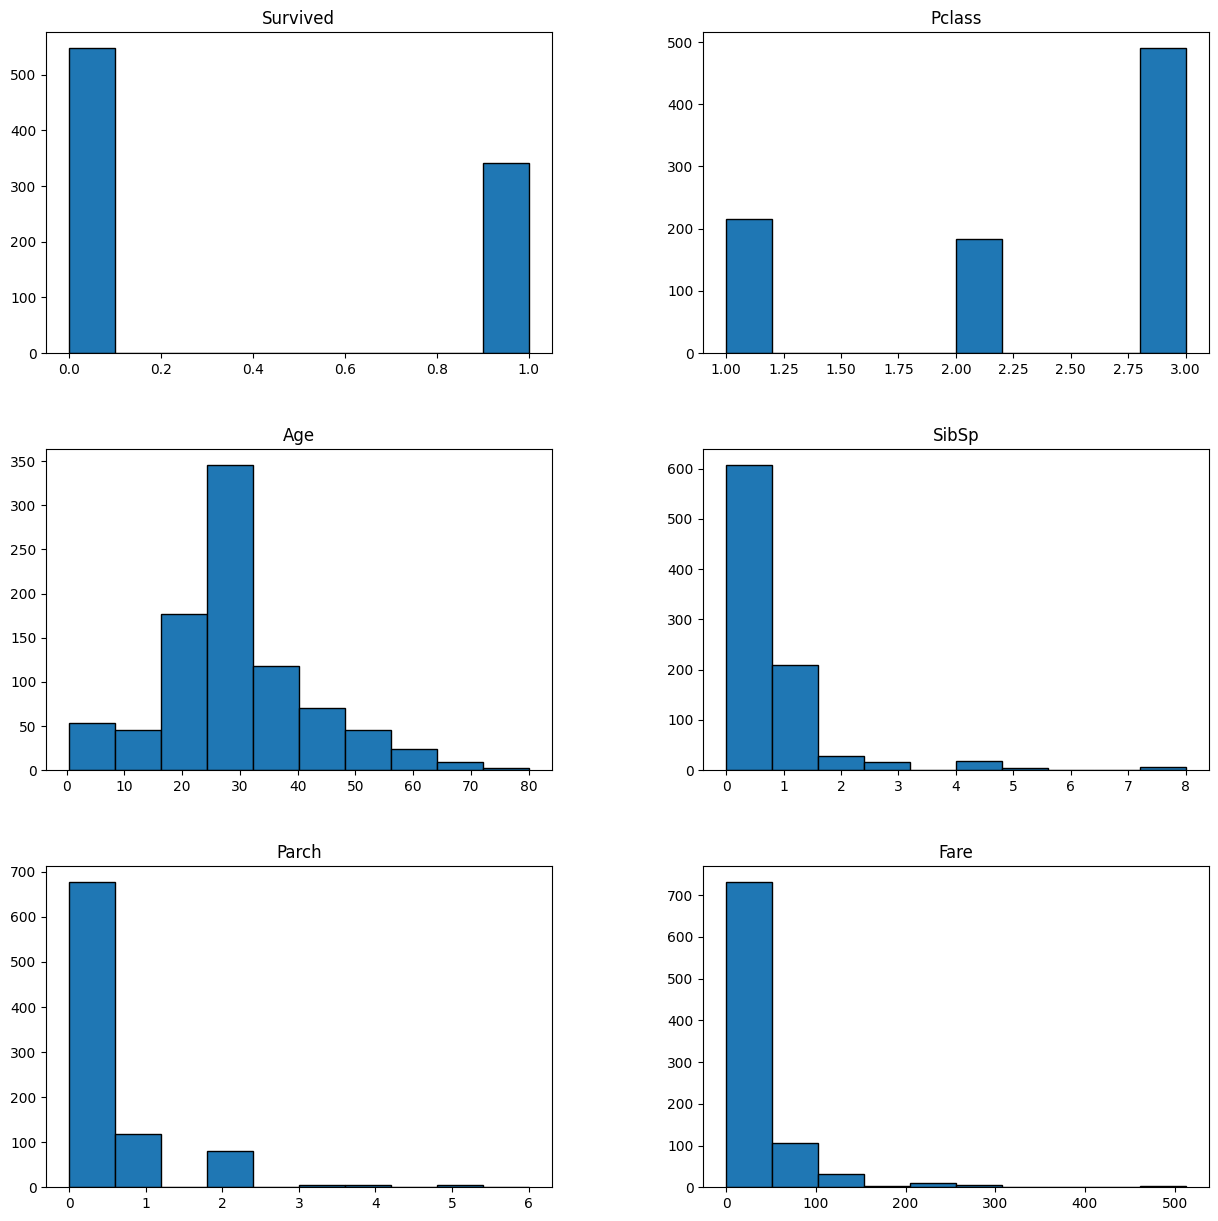

In [132]:
data.hist(edgecolor='black',  figsize=(15, 15), grid=False)

На данном этапе проводится более детальный визуальный обзор структуры данных, где числовые и категориальные признаки рассматриваются одновременно. Такой подход позволяет увидеть не только форму распределений возрастов, стоимости билетов или семейных признаков, но и понять соотношение основных категорий по полу, классу обслуживания, порту отправления и факту выживания.

Text(0.5, 1.0, 'Embarked')

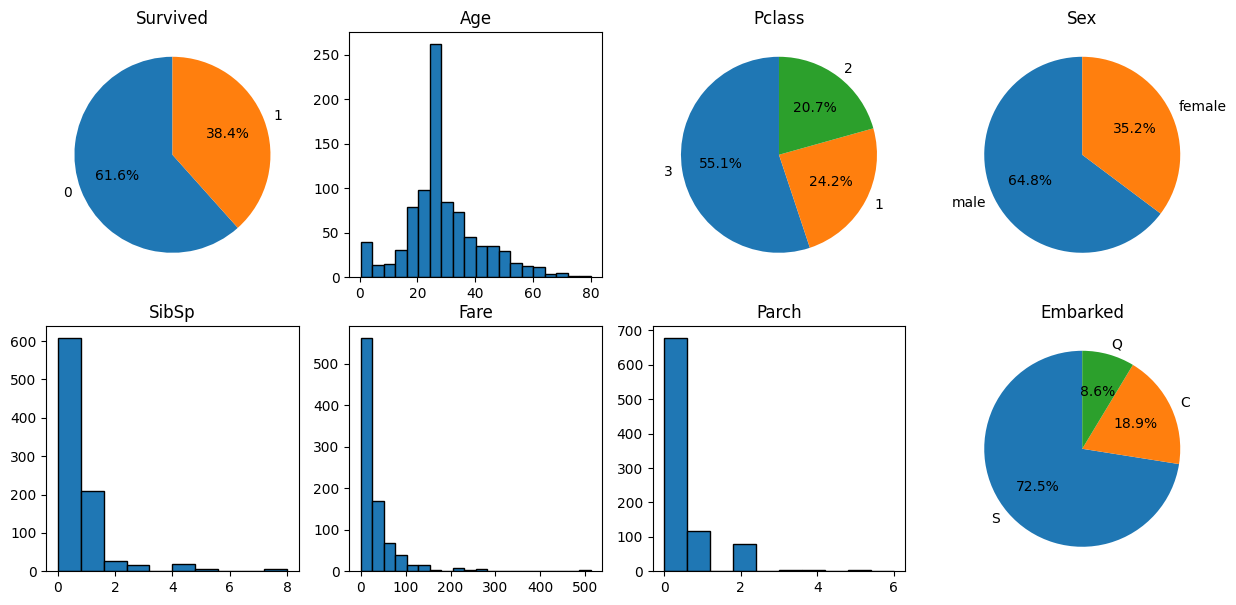

In [133]:
fig, ax = plt.subplots(nrows = 2, ncols = 4, figsize = (15,7))

ax[0,0].pie(data.Survived.value_counts(), labels= data.Survived.value_counts().index, autopct='%1.1f%%', startangle=90)
ax[0,0].set_title('Survived')


ax[0, 1].hist(data.Age, bins=20, edgecolor='black')
ax[0, 1].set_title('Age')

ax[0,2].pie(data.Pclass.value_counts(), labels= data.Pclass.value_counts().index, autopct='%1.1f%%', startangle=90)
ax[0, 2].set_title('Pclass')

ax[0,3].pie(data.Sex.value_counts(), labels= data.Sex.value_counts().index, autopct='%1.1f%%', startangle=90)
ax[0, 3].set_title('Sex')

ax[1,0].hist(data.SibSp, edgecolor='black')
ax[1, 0].set_title('SibSp')

ax[1, 1].hist(data.Fare, bins=20, edgecolor='black')
ax[1, 1].set_title('Fare')

ax[1,2].hist(data.Parch, edgecolor='black')
ax[1, 2].set_title('Parch')

ax[1,3].pie(data.Embarked.value_counts(), labels= data.Embarked.value_counts().index, autopct='%1.1f%%', startangle=90)
ax[1, 3].set_title('Embarked')

### Стандартизация данных

Перед построением модели необходимо стандартизировать числовые переменные и преобразовать категориальные признаки в набор бинарных индикаторов. Масштабирование позволяет выровнять диапазоны значений и избежать ситуации, когда один признак начинается от долей единицы, а другой измеряется десятками, что может исказить работу алгоритмов.

In [134]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num = data.drop(['Embarked', 'Sex'], axis=1)
data_scaled = pd.DataFrame(
    scaler.fit_transform(num),
    columns=num.columns,
    index=data.index
)
data_scaled = pd.concat([data_scaled, pd.get_dummies(data.Embarked, drop_first=False, dtype='int8'), pd.get_dummies(data.Sex, drop_first=False, dtype='int8')], axis=1)
data_scaled.round(2)


,Survived,Pclass,Age,SibSp,Parch,Fare,C,Q,S,female,male
0,-0.79,0.83,-0.57,0.43,-0.47,-0.50,0,0,1,0,1
1,1.27,-1.57,0.66,0.43,-0.47,0.79,1,0,0,1,0
2,1.27,0.83,-0.26,-0.47,-0.47,-0.49,0,0,1,1,0
3,1.27,-1.57,0.43,0.43,-0.47,0.42,0,0,1,1,0
4,-0.79,0.83,0.43,-0.47,-0.47,-0.49,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...
886,-0.79,-0.37,-0.18,-0.47,-0.47,-0.39,0,0,1,0,1
887,1.27,-1.57,-0.80,-0.47,-0.47,-0.04,0,0,1,1,0
888,-0.79,0.83,-0.10,0.43,2.01,-0.18,0,0,1,1,0
889,1.27,-1.57,-0.26,-0.47,-0.47,-0.04,1,0,0,0,1


### Разбиение на тренеровочную и тестовую выборку

Выделим 20% на тестовую выборку и 80% на тренировачную

In [135]:

from sklearn.model_selection import train_test_split

X = data_scaled.drop(['Survived'], axis=1)

y = data['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Наивный Байесовский классификатор (GaussianNB, MultinomialNB, ComplementNB, BernoulliNB)

Наивный байесовский классификатор (Naive Bayes classifier) — вероятностный классификатор на основе формулы Байеса со строгим (наивным) предположением о независимости признаков между собой при заданном классе, что сильно упрощает задачу классификации из-за оценки одномерных вероятностных плотностей вместо одной многомерной

In [136]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

model_nb = GaussianNB()

model_nb.fit(X_train, y_train)

y_predNB = model_nb.predict(X_test)


print(confusion_matrix(y_test, y_predNB))
accuracyNB = accuracy_score(y_test, y_predNB)
recallNB = recall_score(y_test, y_predNB)
precisionNB = precision_score(y_test, y_predNB)
f1NB = f1_score(y_test, y_predNB)
roc_aucNB = roc_auc_score(y_test, y_predNB)
print("Accuracy:", accuracyNB)
print("Recall:", recallNB)
print("Precision:", precisionNB)
print("F1-score:", f1NB)
print("ROC-AUC:", roc_aucNB)



[[81 24]
 [16 58]]
Accuracy: 0.776536312849162
Recall: 0.7837837837837838
Precision: 0.7073170731707317
F1-score: 0.7435897435897436
ROC-AUC: 0.7776061776061777


### Деревья решений (Decision Tree)

Дерево решений – это один из алгоритмов машинного обучения. Алгоритм основан на правиле: «Если <условие>, то <ожидаемый результат>».
Его основная идея заключается в последовательном разбиении исходного множества данных на более мелкие подмножества по признакам, которые наиболее чётко разделяют объекты разных классов. В итоге формируется древовидная структура, где каждая внутренняя вершина соответствует проверке определённого условия ветви – результатам проверки, а листья – конечным классам или числовым значениям, которые предсказывает модель. Обучение дерева решений заключается в выборе таких признаков и порогов разбиения, которые максимально уменьшают неопределённость данных.


In [137]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

model_tree = DecisionTreeClassifier(
    max_depth=3
)

model_tree.fit(X_train, y_train)

y_predTree = model_tree.predict(X_test)

print(confusion_matrix(y_test, y_predTree))
accuracyTree = accuracy_score(y_test, y_predTree)
recallTree = recall_score(y_test, y_predTree)
precisionTree = precision_score(y_test, y_predTree)
f1Tree = f1_score(y_test, y_predTree)
roc_aucTree = roc_auc_score(y_test, y_predTree)

# plt.figure(figsize=(20,9))
# plot_tree(model_tree,
#     filled=True,
#     feature_names=X.columns,
#     class_names=['Died', 'Survived']
#     )
print("Accuracy:", accuracyTree)
print("Recall:", recallTree)
print("Precision:", precisionTree)
print("F1-score:", f1Tree)
print("ROC-AUC:", roc_aucTree)


[[92 13]
 [23 51]]
Accuracy: 0.7988826815642458
Recall: 0.6891891891891891
Precision: 0.796875
F1-score: 0.7391304347826086
ROC-AUC: 0.7826898326898326


### Линейный дискриминантный анализ (Linear Discriminant Analysis)

Линейный дискриминантный анализ (Linear Discriminant Analysis или LDA) — алгоритм классификации и понижения размерности, позволяющий производить разделение классов наилучшим образом. Основная идея LDA заключается в предположении о многомерном нормальном распределении признаков внутри классов и поиске их линейного преобразования, которое максимизирует межклассовую дисперсию и минимизирует внутриклассовую. Другими словами, объекты разных классов должны иметь нормальное распределение и располагаться как можно дальше друг от друга, а одного класса — как можно ближе.

In [138]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

model_LDA = LinearDiscriminantAnalysis()

model_LDA.fit(X_train, y_train)

y_predLDA = model_LDA.predict(X_test)

print(confusion_matrix(y_test, y_predLDA))

accuracyLDA = accuracy_score(y_test, y_predLDA)
recallLDA = recall_score(y_test, y_predLDA)
precisionLDA = precision_score(y_test, y_predLDA)
f1LDA = f1_score(y_test, y_predLDA)
roc_aucLDA = roc_auc_score(y_test, y_predLDA)

print("Accuracy:", accuracyLDA)
print("Recall:", recallLDA)
print("Precision:", precisionLDA)
print("F1-score:", f1LDA)
print("ROC-AUC:", roc_aucLDA)


[[89 16]
 [21 53]]
Accuracy: 0.7932960893854749
Recall: 0.7162162162162162
Precision: 0.7681159420289855
F1-score: 0.7412587412587412
ROC-AUC: 0.781917631917632


### Метод опорных векторов (Support Vector Machines)

Метод опорных векторов, или Support Vector Machine (SVM), — это один из мощных алгоритмов машинного обучения для задач классификации и регрессии. Его основная идея заключается в том, чтобы найти гиперплоскость, максимально разделяющую объекты разных классов в пространстве признаков. При этом алгоритм выбирает такую плоскость, которая обеспечивает наибольший зазор (margin) между классами, то есть расстояние до ближайших объектов обоих классов (опорных векторов) максимально.

In [139]:
from sklearn.svm import SVC

model_SVM = SVC(
    gamma = 'auto'
)

model_SVM.fit(X_train, y_train)

y_predSVM = model_SVM.predict(X_test)

print(confusion_matrix(y_test, y_predSVM))

accuracySVM = accuracy_score(y_test, y_predSVM)
recallSVM = recall_score(y_test, y_predSVM)
precisionSVM = precision_score(y_test, y_predSVM)
f1SVM = f1_score(y_test, y_predSVM)
roc_aucSVM = roc_auc_score(y_test, y_predSVM)

print("Accuracy:", accuracySVM)
print("Recall:", recallSVM)
print("Precision:", precisionSVM)
print("F1-score:", f1SVM)
print("ROC-AUC:", roc_aucSVM)


[[92 13]
 [20 54]]
Accuracy: 0.8156424581005587
Recall: 0.7297297297297297
Precision: 0.8059701492537313
F1-score: 0.7659574468085106
ROC-AUC: 0.802960102960103


### Метод ближайших соседей (k-Nearest Neighbors)

К-ближайших соседей (K-Nearest Neighbors или просто KNN) — алгоритм классификации и регрессии, основанный на гипотезе компактности, которая предполагает, что расположенные близко друг к другу объекты в пространстве признаков имеют схожие значения целевой переменной или принадлежат к одному классу.

In [140]:
from sklearn.neighbors import KNeighborsClassifier

model_KN = KNeighborsClassifier()

model_KN.fit(X_train, y_train)

y_predKN = model_KN.predict(X_test)

print(confusion_matrix(y_test, y_predKN))

accuracyKN = accuracy_score(y_test, y_predKN)
recallKN = recall_score(y_test, y_predKN)
precisionKN = precision_score(y_test, y_predKN)
f1KN = f1_score(y_test, y_predKN)
roc_aucKN = roc_auc_score(y_test, y_predKN)

print("Accuracy:", accuracyKN)
print("Recall:", accuracyKN)
print("Precision:", accuracyKN)
print("F1-score:", accuracyKN)
print("ROC-AUC:", accuracyKN)


[[90 15]
 [21 53]]
Accuracy: 0.7988826815642458
Recall: 0.7988826815642458
Precision: 0.7988826815642458
F1-score: 0.7988826815642458
ROC-AUC: 0.7988826815642458


### Сравнительный анализ методов

In [141]:
rows = [
    {'model': 'Naive Bayes', 'accuracy': accuracyNB, 'recall': recallNB, 'precision': precisionNB, 'f1': f1NB, 'roc': roc_aucNB},
    {'model': 'Decision Tree', 'accuracy': accuracyTree, 'recall': recallTree, 'precision': precisionTree, 'f1': f1Tree, 'roc': roc_aucTree},
    {'model': 'LDA', 'accuracy': accuracyLDA, 'recall': recallLDA, 'precision': precisionLDA, 'f1': f1LDA, 'roc': roc_aucLDA},
    {'model': 'SVM', 'accuracy': accuracySVM, 'recall': recallSVM, 'precision': precisionSVM, 'f1': f1SVM, 'roc': roc_aucSVM},
    {'model': 'KNN', 'accuracy': accuracyKN, 'recall': recallKN, 'precision': precisionKN, 'f1': f1KN, 'roc': roc_aucKN},
]
model_data = pd.DataFrame(rows, columns=['model','accuracy','recall','precision','f1','roc'])

model_data

,model,accuracy,recall,precision,f1,roc
0,Naive Bayes,0.776536,0.783784,0.707317,0.743590,0.777606
1,Decision Tree,0.798883,0.689189,0.796875,0.739130,0.782690
2,LDA,0.793296,0.716216,0.768116,0.741259,0.781918
3,SVM,0.815642,0.729730,0.805970,0.765957,0.802960
4,KNN,0.798883,0.716216,0.779412,0.746479,0.786680


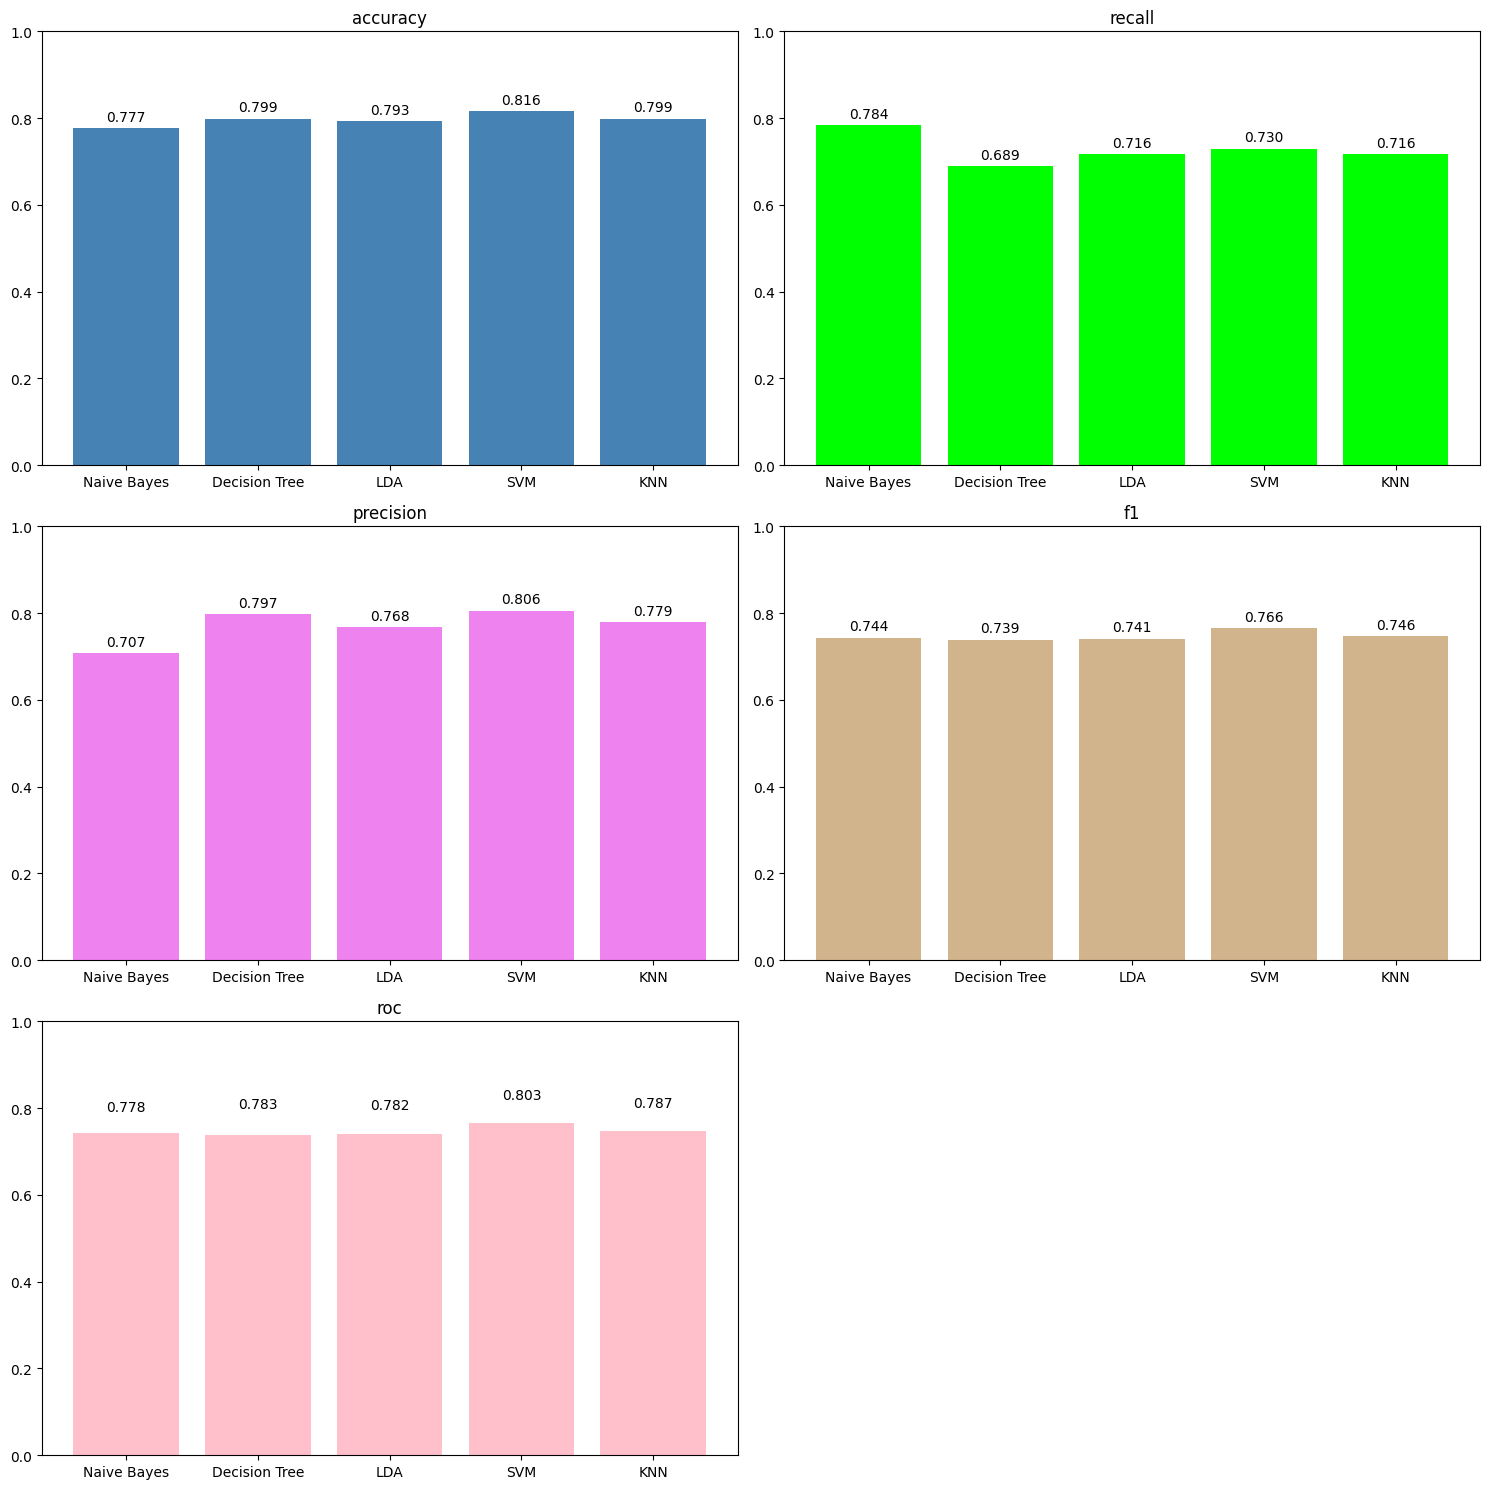

In [142]:
fig, ax = plt.subplots(nrows = 3, ncols = 2, figsize = (15,15))

ax[0,0].bar(model_data['model'], model_data['accuracy'], color='steelblue')
for i, v in enumerate(model_data['accuracy']):
    ax[0,0].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
ax[0,0].set_ylim(0,1)
ax[0,0].set_title('accuracy')

ax[0,1].bar(model_data['model'], model_data['recall'], color='lime')
ax[0,1].set_ylim(0,1)
ax[0,1].set_title('recall')
for i, v in enumerate(model_data['recall']):
    ax[0,1].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

ax[1,0].bar(model_data['model'], model_data['precision'], color='violet')
ax[1,0].set_ylim(0,1)
ax[1,0].set_title('precision')
for i, v in enumerate(model_data['precision']):
    ax[1,0].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

ax[1,1].bar(model_data['model'], model_data['f1'], color='tan')
ax[1,1].set_ylim(0,1)
ax[1,1].set_title('f1')
for i, v in enumerate(model_data['f1']):
    ax[1,1].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

ax[2,0].bar(model_data['model'], model_data['f1'], color='pink')
ax[2,0].set_ylim(0,1)
ax[2,0].set_title('roc')
for i, v in enumerate(model_data['roc']):
    ax[2,0].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

ax[2,1].set_visible(False)

plt.tight_layout()

Лучший результат показал SVM: его accuracy составляет 0.815642, recall достигает 0.729730, precision — 0.805970. Значение f1 поднялось до 0.765957, а roc оказалось на уровне 0.802960. Такое сочетание метрик даёт ощущение уверенной и ровной работы, где модель хорошо различает классы и держит баланс между полнотой и точностью.

Наивный Байес оказался более мягким: accuracy — 0.776536, recall — 0.783784, precision — 0.707317. Здесь заметно, что модель старается находить как можно больше положительных объектов, что и выражается в высоком recall, но делает это ценой более слабого precision. f1 получилось 0.743590, а roc — 0.777606, что отражает этот перекос.

Дерево решений показало интересное сочетание: accuracy 0.798883, recall 0.689189, precision 0.796875. Из-за такого разрыва становится заметно, что дерево уверенно классифицирует найденные положительные примеры, но пропускает значительную их часть. f1 — 0.739130 и roc — 0.782690 подтверждают эту неравномерность.

LDA демонстрирует более спокойный, ровный характер: accuracy составляет 0.793296, recall — 0.716216, precision — 0.768116. Метрика f1 достигает 0.741259, а roc — 0.781918. Здесь нет резких скачков, и все значения сбалансированы, что создаёт впечатление надёжности.

KNN оказался близок к LDA: accuracy 0.798883, recall 0.716216, precision 0.779412. При этом f1 составляет 0.746479, а roc — 0.786680. Модель хорошо работает на плотных участках данных, хотя иногда уступает в ситуациях с разреженными точками.

Если смотреть на все метрики сразу, чётко выстраивается порядок по качеству: первое место занимает SVM, затем идут LDA и KNN, после них — Decision Tree, и замыкает сравнение Naive Bayes, который остаётся стабильным, но уступает более гибким методам по точности и общему балансу метрик.

### Настройте гиперпараметры каждого метода и проведите исследование влияния различных параметров на качество классификации.

##### Наивный Байесовский классификатор

GaussianNB — это var_smoothing. Этот коэффициент сглаживания помогает модели работать устойчивее, особенно если в данных встречаются очень маленькие дисперсии, которые могут приводить к численным ошибкам. Чтобы понять, насколько сильно изменение этого параметра влияет на итоговые метрики, я перебрал значения в широком диапазоне распределённых логарифмически.

In [143]:
parameters = {
    'var_smoothing': np.logspace(-6, 0, 7)
}

results = []

for p in parameters['var_smoothing']:
    model_nb = GaussianNB(var_smoothing=p)
    model_nb.fit(X_train, y_train)
    y_predNB = model_nb.predict(X_test)
    
    acc = accuracy_score(y_test, y_predNB)
    recall = recall_score(y_test, y_predNB)
    precision = precision_score(y_test, y_predNB)
    f1 = f1_score(y_test, y_predNB)
    roc_auc = roc_auc_score(y_test, y_predNB)

    results.append({
        'var_smoothing': p,
        'accuracy': accuracy_score(y_test, y_predNB),
        'recall': recall_score(y_test, y_predNB),
        'precision': precision_score(y_test, y_predNB),
        'f1': f1_score(y_test, y_predNB),
        'roc_auc': roc_auc_score(y_test, y_predNB)
    })

results_NB = pd.DataFrame(results)

results_NB

,var_smoothing,accuracy,recall,precision,f1,roc_auc
0,0.000001,0.776536,0.783784,0.707317,0.74359,0.777606
1,0.000010,0.776536,0.783784,0.707317,0.74359,0.777606
2,0.000100,0.776536,0.783784,0.707317,0.74359,0.777606
3,0.001000,0.776536,0.783784,0.707317,0.74359,0.777606
4,0.010000,0.776536,0.783784,0.707317,0.74359,0.777606
5,0.100000,0.776536,0.729730,0.729730,0.72973,0.769627
6,1.000000,0.715084,0.337838,0.925926,0.49505,0.659395


Результаты подбора var_smoothing, сразу стало видно, что в диапазоне от модель практически не меняет своё поведение: accuracy держится на уровне 0.776536, recall — 0.783784, precision — 0.707317, f1 — 0.74359, roc_auc — 0.777606. Это говорит о том, что GaussianNB в этом интервале стабилен и почти не чувствителен к небольшому сглаживанию.

Когда параметр увеличивается до 0.1, recall заметно снижается до 0.729730, но precision поднимается до 0.729730, а f1 немного падает, что отражает более консервативную стратегию модели.

При var_smoothing = 1.0 качество резко ухудшается: accuracy падает до 0.715084, recall — до 0.337838, хотя precision подскакивает до 0.925926, показывая, что модель почти перестаёт находить положительный класс. Это уже слишком сильное сглаживание, и модель теряет способность различать данные.

##### Деревья решений (Decision Tree)

Для данного метода я выбрал два параметра, которые сильнее всего влияют на поведение модели — criterion и max_depth. Первый определяет способ оценки качества разбиений (gini, entropy, log_loss), а второй задаёт максимальную глубину дерева и напрямую контролирует сложность модели.

In [144]:
parameters = {
    'criterion' : {'gini', 'entropy', 'log_loss'},
    'max_depth' : [None,1,2,3,4,5], 
}
results = []
for crit in parameters['criterion']:
    for depth in parameters['max_depth']:

        model_tree = DecisionTreeClassifier(criterion=crit, max_depth=depth)

        model_tree.fit(X_train, y_train)

        y_predTree = model_tree.predict(X_test)

        results.append({
            'criterion': crit,
            'max_depth': depth,
            'accuracy': accuracy_score(y_test, y_predTree),
            'recall': recall_score(y_test, y_predTree),
            'precision': precision_score(y_test, y_predTree),
            'f1': f1_score(y_test, y_predTree),
            'roc_auc': roc_auc_score(y_test, y_predTree)
        })

results_Tree = pd.DataFrame(results)

results_Tree

,criterion,max_depth,accuracy,recall,precision,f1,roc_auc
0,entropy,NaN,0.765363,0.743243,0.705128,0.723684,0.762098
1,entropy,1.0,0.782123,0.702703,0.753623,0.727273,0.770399
2,entropy,2.0,0.765363,0.500000,0.880952,0.637931,0.726190
3,entropy,3.0,0.798883,0.689189,0.796875,0.739130,0.782690
4,entropy,4.0,0.798883,0.635135,0.839286,0.723077,0.774710
5,entropy,5.0,0.804469,0.662162,0.830508,0.736842,0.783462
6,gini,NaN,0.776536,0.756757,0.717949,0.736842,0.773616
7,gini,1.0,0.782123,0.702703,0.753623,0.727273,0.770399
8,gini,2.0,0.765363,0.500000,0.880952,0.637931,0.726190
9,gini,3.0,0.798883,0.689189,0.796875,0.739130,0.782690


Результаты подбора гиперпараметров для дерева решений сразу показывают, что качество модели сильно зависит от глубины дерева, тогда как выбор критерия влияет гораздо слабее. Когда max_depth не ограничен, accuracy колеблется в диапазоне 0.765–0.782 при стабильном recall около 0.74, что говорит о стремлении дерева усложняться и подстраиваться под данные. Однако при увеличении глубины появляются более выразительные модели: уже на глубине 3 accuracy достигает 0.798883, а комбинации entropy и log_loss при глубине 5 дают максимум — 0.804469 с f1 = 0.736842 и roc_auc ≈ 0.783462.

Особенно заметно, как глубины 2 и 1 ограничивают выразительность: хотя precision поднимается до 0.880952 на глубине 2, общего баланса это не даёт — recall падает до 0.5, и итоговый f1 снижается до 0.637931. Дерево в таких условиях становится слишком «жёстким», делая мало разбиений и ошибаясь на сложных случаях.

Глубины 3–5 оказываются наиболее устойчивыми: метрики стабильно держатся на высоком уровне, а значения accuracy и roc_auc практически совпадают для всех критериев. Это говорит о том, что дерево в первую очередь зависит от max_depth, а выбор criterion влияет только на нюансах. Наилучшие результаты достигаются при глубине 5 с criterion entropy или log_loss — модель в этой точке наиболее эффективно балансирует точность и способность различать классы.

##### Линейный дискриминантный анализ (Linear Discriminant Analysis)

In [145]:
parameters = {
    'solver' : {'svd', 'lsqr'},
}

results = []

for s in parameters['solver']:

        model_LDA = LinearDiscriminantAnalysis(
            solver=s,
        )

        model_LDA.fit(X_train, y_train)

        y_predLDA = model_LDA.predict(X_test)

        results.append({
            'solver': s,
            'accuracy': accuracy_score(y_test, y_predLDA),
            'recall': recall_score(y_test, y_predLDA),
            'precision': precision_score(y_test, y_predLDA),
            'f1': f1_score(y_test, y_predLDA),
            'roc_auc': roc_auc_score(y_test, y_predLDA)
        })

results_LDA = pd.DataFrame(results)

results_LDA


,solver,accuracy,recall,precision,f1,roc_auc
0,svd,0.793296,0.716216,0.768116,0.741259,0.781918
1,lsqr,0.793296,0.716216,0.768116,0.741259,0.781918


Обе версии LDA показали абсолютно одинаковые результаты, и это сразу заметно по метрикам: accuracy = 0.793296, recall = 0.716216, precision = 0.768116, f1 = 0.741259 и roc_auc = 0.781918. Это означает, что изменение solver никак не повлияло на качество классификации в рамках данного набора данных.

Такое совпадение показывает, что структура признаков и их распределение позволяют обоим методам решения работать одинаково эффективно. Модель уверенно различает классы, сохраняя баланс между ошибками первого и второго рода, а сам алгоритм остаётся устойчивым независимо от выбора solver.

##### Метод опорных векторов (Support Vector Machines)

Перед подбором параметров для SVM я сосредоточился на двух ключевых настройках, которые определяют форму разделяющей поверхности и чувствительность модели к изменению масштаба признаков. Я перебрал разные варианты ядра — от линейного до полиномиального, RBF и сигмоидального — чтобы увидеть, как меняется способность алгоритма улавливать сложные зависимости в данных. Вместе с этим я изменял параметр gamma, который контролирует влияние отдельной точки на границу решения, выбирая между значениями scale и auto.

In [146]:
parameters = {
    'kernel' : {'linear', 'poly', 'rbf', 'sigmoid'},
    'gamma': {'scale', 'auto'},
}
results = []
for k in parameters['kernel']:
    for g in parameters['gamma']:
        model_SVM = SVC(
            kernel=k,
            gamma=g
        )

        model_SVM.fit(X_train, y_train)

        y_predSVM = model_SVM.predict(X_test)

        results.append({
            'kernel': k,
            'gamma': g,
            'accuracy': accuracy_score(y_test, y_predSVM),
            'recall': recall_score(y_test, y_predSVM),
            'precision': precision_score(y_test, y_predSVM),
            'f1': f1_score(y_test, y_predSVM),
            'roc_auc': roc_auc_score(y_test, y_predSVM)
        })

results_SVM = pd.DataFrame(results)

results_SVM



,kernel,gamma,accuracy,recall,precision,f1,roc_auc
0,linear,auto,0.782123,0.702703,0.753623,0.727273,0.770399
1,linear,scale,0.782123,0.702703,0.753623,0.727273,0.770399
2,rbf,auto,0.815642,0.729730,0.805970,0.765957,0.802960
3,rbf,scale,0.815642,0.729730,0.805970,0.765957,0.802960
4,sigmoid,auto,0.715084,0.621622,0.666667,0.643357,0.701287
5,sigmoid,scale,0.670391,0.554054,0.611940,0.581560,0.653218
6,poly,auto,0.787709,0.540541,0.909091,0.677966,0.751223
7,poly,scale,0.804469,0.716216,0.791045,0.751773,0.791441


В этих результатах заметно, что наилучшее сочетание устойчивости и качества дают ядра rbf с любым значением gamma, потому что они стабильно держат более высокую точность и уверенно выделяют нужные объекты без сильных перекосов между полнотой и точностью. Линейное ядро сохраняет умеренный уровень качества и ведёт себя предсказуемо, но уступает по способности улавливать сложные зависимости. Поли­ном и особенно сигмоид показывают менее уверенную работу: они реагируют на данные резче, что приводит либо к завышенной точности при низкой полноте, либо к общему падению качества. Поэтому среди всех вариантов rbf выглядит наиболее надёжным выбором, так как лучше улавливает структуру данных и обеспечивает более ровный баланс между метриками.

##### Метод ближайших соседей (k-Nearest Neighbors)

In [147]:
parameters = {
    'n_neighbors' : {3, 4, 5, 6},
    'weights' : {'uniform', 'distance'},
    'algorithm' : {'auto', 'ball_tree', 'kd_tree', 'brute'}
}
results = []

for n in parameters['n_neighbors']:
    for w in parameters['weights']:
        for a in parameters['algorithm']:

            model_KN = KNeighborsClassifier(
                n_neighbors=n,
                weights=w,
                algorithm=a
            )

            model_KN.fit(X_train, y_train)

            y_predKN = model_KN.predict(X_test)

            results.append({
                'n_neighbors': n,
                'weights': w,
                'algorithm' : a,
                'accuracy': accuracy_score(y_test, y_predKN),
                'recall': recall_score(y_test, y_predKN),
                'precision': precision_score(y_test, y_predKN),
                'f1': f1_score(y_test, y_predKN),
                'roc_auc': roc_auc_score(y_test, y_predKN)
            })

results_KN = pd.DataFrame(results)

results_KN

,n_neighbors,weights,algorithm,accuracy,recall,precision,f1,roc_auc
0,3,distance,ball_tree,0.787709,0.729730,0.750000,0.739726,0.779151
1,3,distance,auto,0.787709,0.729730,0.750000,0.739726,0.779151
2,3,distance,brute,0.787709,0.729730,0.750000,0.739726,0.779151
3,3,distance,kd_tree,0.787709,0.729730,0.750000,0.739726,0.779151
4,3,uniform,ball_tree,0.798883,0.716216,0.779412,0.746479,0.786680
5,3,uniform,auto,0.798883,0.716216,0.779412,0.746479,0.786680
6,3,uniform,brute,0.798883,0.716216,0.779412,0.746479,0.786680
7,3,uniform,kd_tree,0.798883,0.716216,0.779412,0.746479,0.786680
8,4,distance,ball_tree,0.782123,0.729730,0.739726,0.734694,0.774389
9,4,distance,auto,0.782123,0.729730,0.739726,0.734694,0.774389


### Реализуйте и протестируйте нейронную сеть на TensorFlow, исследуйте эффект настройки гиперпараметров и визуализируйте процесс обучения с помощью инструмента TensorBoard.

In [ ]:

import tensorflow as tf
import keras



model = keras.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(64, activation=keras.activations.relu),
    keras.layers.Dense(32, activation=keras.activations.relu),
    keras.layers.Dense(1, activation=keras.activations.sigmoid)
])

model.compile(
    optimizer='sgd',
    loss = keras.losses.binary_crossentropy,
    metrics=['accuracy']
)


history = model.fit(
    np.array(X_train),
    np.array(y_train), 
    epochs=10,
    verbose=0,
    shuffle=True,  
)

predictions = model.predict(X_test)

binary_predict = (predictions > 0.5).astype(int)

predictions


print(confusion_matrix(y_test, binary_predict))


accuracyNT = accuracy_score(y_test, binary_predict)
recallNT = recall_score(y_test, binary_predict)
precisionNT = precision_score(y_test, binary_predict)
f1NT = f1_score(y_test, binary_predict)
roc_aucNT = roc_auc_score(y_test, binary_predict)

print(accuracyNT)
print(recallNT)
print(precisionNT)
print(f1NT)
print(roc_aucNT)



6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
[[91 14]
 [20 54]]
0.8100558659217877
0.7297297297297297
0.7941176470588235
0.7605633802816901
0.7981981981981983
